# E4 - augmentation ablation

Last ablation in the study. Only change from the baseline run: training transform uses `augment=False` instead of `augment=True`. Val set was already unaugmented, so nothing changes there. Everything else (architecture, optimizer, loss, schedule, seed) is identical to baseline.

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from citrus_model import CitrusNet, init_weights
from citrus_common import get_transforms, CitrusLeafDataset
from citrus_train import set_seed, train_one_epoch, evaluate, fit

Normalization stats and class weights, same values used everywhere else in this project.

In [2]:
# from normalization_stats.json
mean = (0.5257163855539984, 0.5160105040026677, 0.34659739807732487)
std = (0.21506874681810037, 0.20516077417601286, 0.22465844151318715)

# order: aphids, gummosis, healthy, leaf_minnor
class_weights = torch.tensor([0.9921, 0.9240, 1.1880, 0.9363], dtype=torch.float32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Datasets. Train transform drops augmentation (`augment=False`), val stays as always.

In [3]:
set_seed(42)

size = 224
data_root = "processed/224"

train_transform = get_transforms(augment=False, mean=mean, std=std, size=size)
val_transform = get_transforms(augment=False, mean=mean, std=std, size=size)

train_dataset = CitrusLeafDataset(root_dir=data_root, split="train", transform=train_transform)
val_dataset = CitrusLeafDataset(root_dir=data_root, split="val", transform=val_transform)

len(train_dataset), len(val_dataset)

(1131, 242)

In [4]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

Model, optimizer, loss, schedule - all identical to baseline.

In [5]:
model = CitrusNet(num_classes=4).to(device)
init_weights(model)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

sum(p.numel() for p in model.parameters())

416036

Train.

In [6]:
os.makedirs("checkpoints", exist_ok=True)

history_no_aug = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    device=device,
    max_epochs=100,
    early_stop_patience=10,
    checkpoint_path="checkpoints/no_aug_best.pt",
)

history_no_aug = pd.DataFrame(history_no_aug)
history_no_aug.to_csv("history_no_aug.csv", index=False)
history_no_aug.tail()

epoch   1  train_loss 0.6320  train_acc 0.7471  val_loss 0.1900  val_acc 0.9504  lr 1.00e-03
epoch   2  train_loss 0.2518  train_acc 0.9160  val_loss 0.1022  val_acc 0.9504  lr 1.00e-03
epoch   3  train_loss 0.1069  train_acc 0.9752  val_loss 0.1872  val_acc 0.9339  lr 1.00e-03
epoch   4  train_loss 0.0691  train_acc 0.9814  val_loss 0.0326  val_acc 0.9917  lr 1.00e-03
epoch   5  train_loss 0.0708  train_acc 0.9823  val_loss 0.1730  val_acc 0.9339  lr 1.00e-03
epoch   6  train_loss 0.1314  train_acc 0.9558  val_loss 0.3949  val_acc 0.8636  lr 1.00e-03
epoch   7  train_loss 0.0590  train_acc 0.9859  val_loss 0.0194  val_acc 0.9959  lr 1.00e-03
epoch   8  train_loss 0.0750  train_acc 0.9814  val_loss 0.0196  val_acc 1.0000  lr 1.00e-03
epoch   9  train_loss 0.0334  train_acc 0.9920  val_loss 0.0597  val_acc 0.9752  lr 1.00e-03
epoch  10  train_loss 0.0425  train_acc 0.9876  val_loss 0.0031  val_acc 1.0000  lr 1.00e-03
epoch  11  train_loss 0.0422  train_acc 0.9903  val_loss 0.0092  val_a

,train_loss,train_acc,val_loss,val_acc,lr,best_epoch,best_val_loss
75,0.002259,1.0,0.000100,1.0,0.000004,70,0.00007
76,0.001187,1.0,0.000095,1.0,0.000004,70,0.00007
77,0.001393,1.0,0.000090,1.0,0.000002,70,0.00007
78,0.001042,1.0,0.000085,1.0,0.000002,70,0.00007
79,0.000943,1.0,0.000077,1.0,0.000002,70,0.00007


Baseline (with augmentation) is already trained - just load its history for comparison.

In [11]:
if "epoch" not in history_no_aug.columns:
    history_no_aug.insert(0, "epoch", history_no_aug.index + 1)
history_no_aug.to_csv("history_no_aug.csv", index=False)
history_no_aug.tail()

,epoch,train_loss,train_acc,val_loss,val_acc,lr,best_epoch,best_val_loss
75,76,0.002259,1.0,0.000100,1.0,0.000004,70,0.00007
76,77,0.001187,1.0,0.000095,1.0,0.000004,70,0.00007
77,78,0.001393,1.0,0.000090,1.0,0.000002,70,0.00007
78,79,0.001042,1.0,0.000085,1.0,0.000002,70,0.00007
79,80,0.000943,1.0,0.000077,1.0,0.000002,70,0.00007


In [17]:
history_baseline = pd.read_csv("history_baseline.csv")
if "epoch" not in history_baseline.columns:
    history_baseline.insert(0, "epoch", history_baseline.index + 1)
history_baseline.tail()

,epoch,train_loss,train_acc,val_loss,val_acc,lr
35,36,0.034279,0.987622,0.001464,1.0,0.000250
36,37,0.020948,0.997347,0.001037,1.0,0.000250
37,38,0.032851,0.992042,0.001129,1.0,0.000125
38,39,0.021557,0.997347,0.001455,1.0,0.000125
39,40,0.018459,0.993811,0.001163,1.0,0.000125


Summary table.

In [18]:
def summarize(history, config_name):
    best_idx = history["val_loss"].idxmin()
    reach_99 = history[history["val_acc"] >= 0.99]
    final_train_acc = history["train_acc"].iloc[-1]
    final_val_acc = history["val_acc"].iloc[-1]
    return {
        "config": config_name,
        "epochs_run": int(history["epoch"].max()),
        "best_epoch": int(history.loc[best_idx, "epoch"]),
        "best_val_loss": history.loc[best_idx, "val_loss"],
        "best_val_acc": history.loc[best_idx, "val_acc"],
        "epochs_to_reach_99pct": int(reach_99["epoch"].iloc[0]) if len(reach_99) else None,
        "final_train_acc": final_train_acc,
        "final_val_acc": final_val_acc,
        "train_val_acc_gap": final_train_acc - final_val_acc,
    }

summary_df = pd.DataFrame([
    summarize(history_no_aug, "no_augmentation"),
    summarize(history_baseline, "with_augmentation"),
])
print(summary_df.to_string(index=False))
summary_df

           config  epochs_run  best_epoch  best_val_loss  best_val_acc  epochs_to_reach_99pct  final_train_acc  final_val_acc  train_val_acc_gap
  no_augmentation          80          70       0.000070           1.0                      4         1.000000            1.0           0.000000
with_augmentation          40          30       0.001026           1.0                      4         0.993811            1.0          -0.006189


,config,epochs_run,best_epoch,best_val_loss,best_val_acc,epochs_to_reach_99pct,final_train_acc,final_val_acc,train_val_acc_gap
0,no_augmentation,80,70,0.000070,1.0,4,1.000000,1.0,0.000000
1,with_augmentation,40,30,0.001026,1.0,4,0.993811,1.0,-0.006189


Plots. (a) val loss on a log scale, (b) val accuracy, both overlaid across configs.

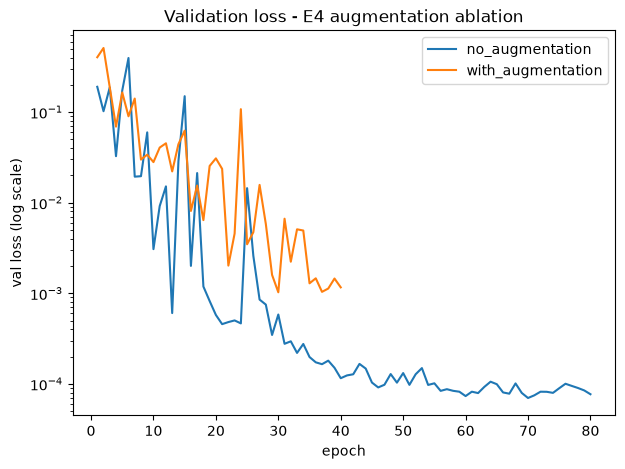

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(history_no_aug["epoch"], history_no_aug["val_loss"], label="no_augmentation")
plt.plot(history_baseline["epoch"], history_baseline["val_loss"], label="with_augmentation")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("val loss (log scale)")
plt.title("Validation loss - E4 augmentation ablation")
plt.legend()
plt.show()

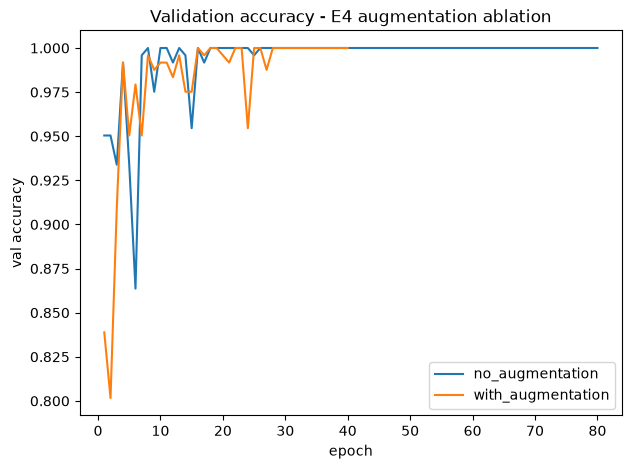

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(history_no_aug["epoch"], history_no_aug["val_acc"], label="no_augmentation")
plt.plot(history_baseline["epoch"], history_baseline["val_acc"], label="with_augmentation")
plt.xlabel("epoch")
plt.ylabel("val accuracy")
plt.title("Validation accuracy - E4 augmentation ablation")
plt.legend()
plt.show()

Train vs val loss for each config separately, side by side, to see the shape of any divergence rather than just a final-epoch number.

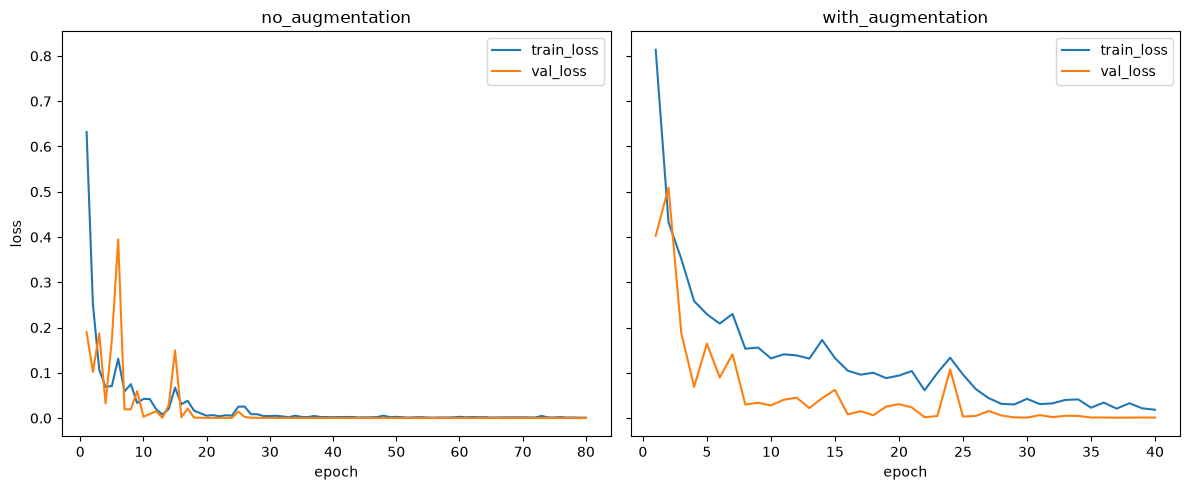

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(history_no_aug["epoch"], history_no_aug["train_loss"], label="train_loss")
axes[0].plot(history_no_aug["epoch"], history_no_aug["val_loss"], label="val_loss")
axes[0].set_title("no_augmentation")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(history_baseline["epoch"], history_baseline["train_loss"], label="train_loss")
axes[1].plot(history_baseline["epoch"], history_baseline["val_loss"], label="val_loss")
axes[1].set_title("with_augmentation")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

Summary.

In [22]:
row_no_aug = summary_df[summary_df["config"] == "no_augmentation"].iloc[0]
row_baseline = summary_df[summary_df["config"] == "with_augmentation"].iloc[0]

no_aug_r99 = row_no_aug["epochs_to_reach_99pct"]
base_r99 = row_baseline["epochs_to_reach_99pct"]

if pd.notna(no_aug_r99) and pd.notna(base_r99):
    faster = "no_augmentation" if no_aug_r99 < base_r99 else "with_augmentation"
    print(f"Faster to reach 99% val accuracy: {faster} ({int(no_aug_r99)} vs {int(base_r99)} epochs)")
else:
    print("epochs_to_reach_99pct not available for one or both configs")

lower_loss = "no_augmentation" if row_no_aug["best_val_loss"] < row_baseline["best_val_loss"] else "with_augmentation"
print(f"Lower best val loss: {lower_loss} ({row_no_aug['best_val_loss']:.5f} vs {row_baseline['best_val_loss']:.5f})")

gap = row_no_aug["train_val_acc_gap"]
print(f"train_val_acc_gap without augmentation: {gap:.4f}")
if gap <= 0.01:
    print("Gap is near zero - no meaningful overfitting from removing augmentation.")
else:
    print("Gap is clearly positive - removing augmentation introduced some overfitting.")

print("See the side-by-side plot above for how the train/val curves behave in each config.")

Faster to reach 99% val accuracy: with_augmentation (4 vs 4 epochs)
Lower best val loss: no_augmentation (0.00007 vs 0.00103)
train_val_acc_gap without augmentation: 0.0000
Gap is near zero - no meaningful overfitting from removing augmentation.
See the side-by-side plot above for how the train/val curves behave in each config.
